<a href="https://colab.research.google.com/github/jenriver/tiny-transformer/blob/main/tiny_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import jax
import jax.numpy as jnp
import random

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [2]:
jax.devices()

[TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]

In [3]:
chars_str = "0123456789+="
pad_str = "_"
MAX_LEN = len("999+999=1998")

def make_vocab(chars_str: str):
  return list(pad_str + chars_str)
vocab = make_vocab(chars_str)
print(vocab)
pad_id = vocab.index(pad_str)

['_', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '=']


In [4]:
def encode(s_in: str) -> list[int]:
  output = []
  for s in s_in:
    output.append(vocab.index(s))
  return output

def decode(ids: list[int]) -> str:
  s = ""
  for i in ids:
    s += vocab[i]
  return s

def rand_ndigit(n):
    return random.randint(0, 9) if n == 1 else random.randint(10**(n-1), 10**n - 1)

def make_example(max_digits=3) -> str:
    a = rand_ndigit(random.randint(1, max_digits))
    b = rand_ndigit(random.randint(1, max_digits))
    return f'{a}+{b}={a+b}'

def make_input_target(ids):
  return ids[:-1], ids[1:]

def pad_to(ids: list[int], T: int) -> tuple[list[int], list[int]]:
  n = len(ids)
  padded = ids + [pad_id] * (T-n)
  mask = [1] * n + [0] * (T-n)
  return padded, mask

def make_batch(B: int, T: int):
  inputs, targets, masks = [], [], []
  for _ in range(B):
    ids = encode(make_example()) + [pad_id]  # important! varied length
    input, target = make_input_target(ids)
    input_padded, mask = pad_to(input, T)
    target_padded, _ = pad_to(target, T)
    inputs.append(input_padded)
    targets.append(target_padded)
    masks.append(mask)
  return jnp.array(inputs), jnp.array(targets), jnp.array(masks)

input = "12+34="
print(encode(input))
print(decode(encode(input)))

[2, 3, 11, 4, 5, 12]
12+34=


In [5]:
def init_embed(key, V, D):
  return jax.random.normal(key, (V, D)) * (1.0 / jnp.sqrt(D))

def embed(table, ids):
  return table[ids]  # fancy-indexing gathers

def init_pos(key, T, D):
  return jax.random.normal(key, (T, D)) * (1.0 / jnp.sqrt(D))

def embed_tokens(tok_table, pos_table, ids):
  B, Tn = ids.shape
  x = tok_table[ids]
  x = x + pos_table[jnp.arange(Tn)]
  return x


In [6]:
def init_attn(key, D, N, K, H):
  kq, kk, kv, ko = jax.random.split(key, 4)
  scale = 1.0 / jnp.sqrt(D)
  return {
      "Wq": jax.random.normal(kq, (D, N, H)) * scale,
      "Wk": jax.random.normal(kk, (D, K, H)) * scale,
      "Wv": jax.random.normal(kv, (D, K, H)) * scale,
      "Wo": jax.random.normal(ko, (N, H, D)) * scale,
  }

def attention(input: jnp.ndarray, attn: dict):
  B, T, D = input.shape
  q = jnp.einsum("btd,dnh->btnh", input, attn["Wq"])
  k = jnp.einsum("bsd,dkh->bskh", input, attn["Wk"])
  v = jnp.einsum("bsd,dnh->bsnh", input, attn["Wv"])

  attn_matrix = jnp.einsum("btnh,bsnh->btsn", q, k) / jnp.sqrt(H)
  S = k.shape[1]
  causal = jnp.tril(jnp.ones((T, S), dtype=bool))
  attn_matrix = jnp.where(causal[None, :, :, None], attn_matrix, -1e30)

  w = jax.nn.softmax(attn_matrix, axis=2)
  scaled_dot_product = jnp.einsum("btsn,bsnh->btnh", w, v)
  return jnp.einsum("btnh,nhd->btd", scaled_dot_product, attn["Wo"])


def init_mlp(key, D, F):
  kw1, kw2, kw3 = jax.random.split(key, 3)
  return {
      "w_gate": jax.random.normal(kw1, (D, F)) / jnp.sqrt(D),
      "w_up":   jax.random.normal(kw2, (D, F)) / jnp.sqrt(D),
      "w_down": jax.random.normal(kw3, (F, D)) / jnp.sqrt(F),
  }

def mlp(input: jnp.ndarray, p: dict):
  B, T, D = input.shape
  gate = jnp.einsum("btd,df->btf", input, p["w_gate"])
  up =   jnp.einsum("btd,df->btf", input, p["w_up"])
  return jnp.einsum("btf,fd->btd", jax.nn.silu(gate) * up, p["w_down"])

def init_norm(D):
  return {'g': jnp.ones(D)}

def rmsnorm(x, p, eps=1e-6):
  ms = jnp.mean(x**2, axis=-1, keepdims=True)
  return x * jax.lax.rsqrt(ms + eps) * p["g"]

def init_block(key, D, N, K, H, F):
  ka, km = jax.random.split(key, 2)
  return {
      "attn": init_attn(ka, D, N, K, H),
      "mlp":   init_mlp(km, D, F),
      "norm1":  init_norm(D),
      "norm2":  init_norm(D),
  }

def init_blocks(key, D, N, K, H, F, L):
  return [init_block(kb, D, N, K, H, F) for kb in jax.random.split(key, L)]

def block(x: jnp.ndarray, p: dict):
  x = x + attention(rmsnorm(x, p['norm1']), p['attn'])
  x = x + mlp(rmsnorm(x, p['norm2']), p['mlp'])
  return x

def init_model(key, V, T, D, N, K, H, F, L):
  kt, kp, kb, ku = jax.random.split(key, 4)
  return {
      "tok_table": init_embed(kt, V, D),
      "pos_table": init_embed(kp, T, D),
      "blocks": init_blocks(kb, D, N, K, H, F, L),
      "norm": init_norm(D),
      "unembed": jax.random.normal(ku, (D, V)) / jnp.sqrt(D),
  }

def model(ids, mp):
  x = embed_tokens(mp["tok_table"], mp["pos_table"], ids)
  for p in mp['blocks']:
    x = block(x, p)
  x = rmsnorm(x, mp['norm'])
  x = jnp.einsum('btd,dv->btv', x, mp['unembed'])
  return x


In [7]:
B = 128
T = MAX_LEN
D = 128
N = 4   # number of heads for query
H = 32  # 128 / 4 = 32 (head dim)
K = 4   # = N for MHA
F = 512 # 4 * D
L = 4
V = len(vocab)


ids, targets, masks = make_batch(B, T)
key = jax.random.PRNGKey(0)
params = init_model(key, V, T, D, N, K, H, F, L)
x = model(ids, params)
print(decode(jnp.argmax(x, axis=-1)[0].tolist()))

08686008=3=0


In [8]:
print(sum(p.size for p in jax.tree.leaves(params)))
print(x.shape)  # B, T, V
print(jnp.isnan(x).any())

1054592
(128, 12, 13)
False


In [9]:
print((V * D) + (T * D) + ((3 * D * F) + (4 * D * N * H) + (2 * D)) * L + D + (V * D))

1054592


## Training

In [10]:
import numpy as np
import optax
import math

def loss_fn(params, ids, targets, mask):
  logits = model(ids, params)
  # logp = jax.nn.log_softmax(logits, axis=-1)
  # tgt = jnp.take_along_axis(logp, targets[..., None], -1)[..., 0]
  # return -(tgt * mask).sum() / mask.sum()
  ce = optax.softmax_cross_entropy_with_integer_labels(logits, targets)   # [B,T]
  return (ce * mask).sum() / mask.sum()

opt = optax.adamw(3e-4)
opt_state = opt.init(params)

@jax.jit
def train_step(params, opt_state, ids, targets, masks):
    loss, grads = jax.value_and_grad(loss_fn)(params, ids, targets, masks)
    gnorm = optax.global_norm(grads)  # ← is it actually learning?
    updates, opt_state = opt.update(grads, opt_state, params)
    return optax.apply_updates(params, updates), opt_state, loss, gnorm

@jax.jit
def accuracy(params, ids, targets, masks):
    pred = jnp.argmax(model(ids, params), -1)
    return ((pred == targets) * masks).sum() / masks.sum()

def sample(params, prompt="456+789="): # "456+789="  # "12+34="
    ids_ = jnp.array([encode(prompt) + [pad_id]*(T-len(prompt))])
    for i in range(len(prompt), T):
        nxt = jnp.argmax(model(ids_, params)[0, i-1])
        if nxt == pad_id: break  # early stopping
        ids_ = ids_.at[0, i].set(nxt)
    return decode(ids_[0].tolist())


In [11]:
print(loss_fn(params, ids, targets, masks))

# floor: loss = −log(1/V) = log(V) = ln(13) ≈ 2.565
print(f'loss floor: {math.log(V):.2f}')

2.979609
loss floor: 2.56


In [12]:
PROBES = {
  "1d_nocarry": [(3,4),(1,2),(5,3),(2,6)],
  "1d_carry":   [(7,8),(9,6),(5,9),(8,4)],
  "2d_nocarry": [(12,34),(21,45),(53,26),(31,44)],
  "2d_carry":   [(18,34),(57,68),(29,13),(46,37)],
  "3d_nocarry": [(123,456),(321,234),(412,145)],
  "3d_carry":   [(456,789),(678,543),(199,282)],
  "cascade":    [(999,1),(99,1),(199,801),(909,91)],
}

def batch_generate(params, prompts):
    arr  = jnp.array([encode(p) + [pad_id]*(T-len(p)) for p in prompts])
    lens = jnp.array([len(p) for p in prompts])
    for i in range(int(lens.min()), T):
        nxt   = jnp.argmax(model(arr, params)[:, i-1], -1)
        write = i >= lens                                   # don't overwrite prompts
        arr   = arr.at[:, i].set(jnp.where(write, nxt, arr[:, i]))
    return [decode(r.tolist()).split(pad_str)[0] for r in arr]   # cut at first PAD

def evaluate(params):
    flat = [(b,a,c) for b,ps in PROBES.items() for a,c in ps]
    outs = batch_generate(params, [f"{a}+{c}=" for _,a,c in flat])
    res  = {}
    for (b,a,c), out in zip(flat, outs):
        res.setdefault(b, []).append(out == f"{a}+{c}={a+c}")
    return {b: sum(v)/len(v) for b,v in res.items()}, dict(zip(
            [(a,c) for _,a,c in flat], [o == f"{a}+{c}={a+c}" for (_,a,c),o in zip(flat,outs)]))

def show_table(first_solve, PROBES, last_step):
    print(f"{'category':14}{'solved':>8}{'median':>9}{'range':>16}")
    print("─" * 47)
    for c, items in PROBES.items():
        steps = [first_solve[i] for i in items if i in first_solve]
        k, n = len(steps), len(items)
        med = int(np.median(steps)) if k else "—"
        rng = f"({min(steps)}–{max(steps)})" if k else "—"
        print(f"{c:14}{f'{k}/{n}':>8}{str(med):>9}{rng:>16}")
    print(f"\nunsolved = censored (>{last_step} steps) — don't drop them from the story")

# ---- trackers ----
emergence  = {b: [] for b in PROBES}     # (step, accuracy) curves
first_solve = {}                          # (a,b) -> step first solved

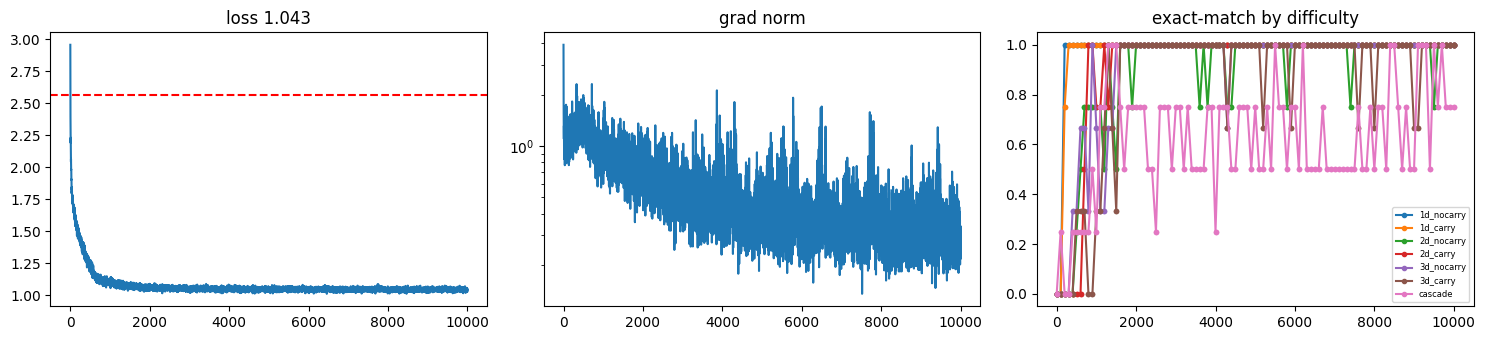

step 10000  sample: '456+789=1245'
{'1d_nocarry': '1.00', '1d_carry': '1.00', '2d_nocarry': '1.00', '2d_carry': '1.00', '3d_nocarry': '1.00', '3d_carry': '1.00', 'cascade': '0.75'}
category        solved   median           range
───────────────────────────────────────────────
1d_nocarry         4/4      200       (200–200)
1d_carry           4/4      200       (200–300)
2d_nocarry         4/4      650       (500–800)
2d_carry           4/4      750       (700–800)
3d_nocarry         3/3      500       (400–900)
3d_carry           3/3     1200      (500–1300)
cascade            4/4      650      (100–1100)

unsolved = censored (>10000 steps) — don't drop them from the story


In [13]:
import matplotlib.pyplot as plt, math
from IPython.display import clear_output

# ---------------- training loop ----------------
params  = init_model(key, V, T, D, N, K, H, F, L)
opt     = optax.adamw(3e-4)
opt_state = opt.init(params)
hist = {"loss": [], "gnorm": [], "acc": []}
EVAL_EVERY = 100

for step in range(10001):
    ids, targets, masks = make_batch(B, T)                 # FRESH batch each step
    params, opt_state, loss, gnorm = train_step(params, opt_state, ids, targets, masks)
    hist["loss"].append(float(loss)); hist["gnorm"].append(float(gnorm))

    if step % EVAL_EVERY == 0:
        accs, per_ex = evaluate(params)          # ← ONCE (you call it twice)
        for b, a in accs.items(): emergence[b].append((step, a))
        for prob, ok in per_ex.items():
            if ok and prob not in first_solve:
                first_solve[prob] = step
                print(f"step {step}: SOLVED {prob[0]}+{prob[1]}={prob[0]+prob[1]}")

        accs, per_ex = evaluate(params)
        for b, a in accs.items(): emergence[b].append((step, a))
        for prob, ok in per_ex.items():
            if ok and prob not in first_solve:
                first_solve[prob] = step
                print(f"step {step}: FIRST SOLVED {prob[0]}+{prob[1]}={prob[0]+prob[1]}")

        clear_output(wait=True)
        fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
        ax[0].plot(hist["loss"]); ax[0].axhline(math.log(V), ls='--', c='r'); ax[0].set_title(f"loss {loss:.3f}")
        ax[1].plot(hist["gnorm"]); ax[1].set_yscale('log'); ax[1].set_title("grad norm")
        for b, pts in emergence.items():
            if pts: ax[2].plot(*zip(*pts), marker='o', ms=3, label=b)
        ax[2].set_ylim(-.05,1.05); ax[2].legend(fontsize=6); ax[2].set_title("exact-match by difficulty")
        plt.tight_layout(); plt.show()
        print(f"step {step}  sample: {sample(params)!r}")
        print({b: f"{a:.2f}" for b,a in accs.items()})

show_table(first_solve, PROBES, 10000)